# ML Algorithms from Scratch

This notebook is for creating Linear Regression algorithms from scratch and testing them on California housing dataset.

## Libraries 

In [134]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
    
)

## Optimizers

In [135]:
def gradient():
    pass
def loss():
    pass


def mini_batch_GD(X_train, y_train, B=32, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X_train.shape

    rng = np.random.default_rng(random_state)
    
    loss_ = []
    parameters = rng.normal(loc=0.0, scale=0.1, size = X_train.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]

    for epoch in range(epochs):

        indices = rng.permutation(n_samples)
        for start in range(0, n_samples, B):

            batch_indices = indices[start: start + B]
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]
            
            grad_w, grad_b = gradient(X_batch, y_batch, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        loss_.append(loss(X_train, y_train, w_, b))
        

    return loss_, w_, b


def mini_batch_GD_val(X_train, y_train, X_val, y_val, B=32, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X_train.shape

    rng = np.random.default_rng(random_state)
    
    loss_ = []
    val_loss_ = []

    parameters = rng.normal(loc=0.0, scale=0.1, size = X_train.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]

    patience = 20
    patience_counter = 0
    best_val_loss = float("inf")
    stop_epoch = epochs
    best_w_ = w_.copy()
    best_b = b
    
    for epoch in range(epochs):
        indices = rng.permutation(n_samples)
        for start in range(0, n_samples, B):
        
            batch_indices = indices[start: start + B]
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]
            
            grad_w, grad_b = gradient(X_batch, y_batch, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        val_loss = loss(X_val, y_val, w_, b)

        loss_.append(loss(X_train, y_train, w_, b))
        val_loss_.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_w_ = w_.copy()
            best_b = b
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            stop_epoch = epoch + 1
            break
        

    return stop_epoch, best_val_loss, val_loss_, loss_, best_w_, best_b


def SGD(X, y, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X.shape

    rng = np.random.default_rng(random_state)

    loss_ = []
    parameters = rng.normal(loc=0.0, scale=0.1, size = X.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]

    for _ in range(epochs):
        indices = rng.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n_samples):
            x_i = X_shuffled[i: i+1]
            y_i = y_shuffled[i: i+1]

            grad_w, grad_b = gradient(x_i, y_i, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        loss_.append(loss(X, y, w_, b))

    return loss_, w_, b

def SGD_val(X_train, y_train, X_val, y_val, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X_train.shape

    rng = np.random.default_rng(random_state)

    loss_ = []
    val_loss_ = []

    parameters = rng.normal(loc=0.0, scale=0.1, size = X_train.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]


    patience = 20
    patience_counter = 0
    best_val_loss = float("inf")
    stop_epoch = epochs
    best_w_ = w_.copy()
    best_b = b
    for epoch in range(epochs):
        indices = rng.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        for i in range(n_samples):
            x_i = X_shuffled[i: i+1]
            y_i = y_shuffled[i: i+1]

            grad_w, grad_b = gradient(x_i, y_i, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        val_loss = loss(X_val, y_val, w_, b)
        
        loss_.append(loss(X_train, y_train, w_, b))
        val_loss_.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_w_ = w_.copy()
            best_b = b
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            stop_epoch = epoch + 1
            break

    return stop_epoch, best_val_loss, val_loss_, loss_, best_w_, best_b
    

## Helper functions

In [136]:

def net_input(X, w_, b):
    return X @ w_ + b

def max_eignvalue(X, w_, b):
    H = (X.T @ X) / X.shape[0]
    eigenvalues = np.linalg.eigvalsh(H)
    return eigenvalues.max()

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w_, b):
    return sigmoid(net_input(X, w_, b))

def predict(X, w_, b):
    return (predict_proba(X, w_, b) >= 0.5).astype(int)

def loss(X, y, w_, b):
    p = predict_proba(X, w_, b)

    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)

    return -np.mean(
        y * np.log(p)
        + (1 - y) * np.log(1 - p)
    )

def gradient(X, y, w_, b):
    errors = predict(X, w_, b) - y

    grad_w = X.T @ errors / len(X)
    grad_b = np.mean(errors)

    return grad_w, grad_b


## Analysis and Visualization of Dataset

In [137]:
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["target"] = cancer.target
df["diagnosis"] = df["target"].map({
    0: "malignant",
    1: "benign"
})

# Arrays for model training
X = cancer.data
y = cancer.target

indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

# Split: 60% train, 20% validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# Fit scaling on training data only, then transform all partitions
scaler = StandardScaler()

X_train_val = scaler.fit_transform(X_train_val)
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


### 1. Class balance

Text(0.5, 1.0, 'Class Distribution')

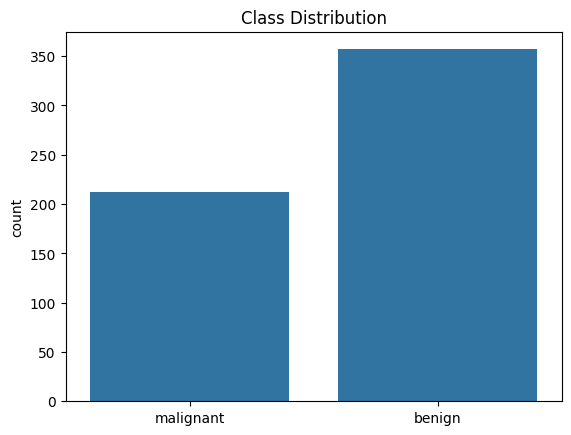

In [138]:
sns.countplot(x=y)
plt.xticks([0, 1], ["malignant", "benign"])
plt.title("Class Distribution")

### 2. Feature distributions by class

<Axes: xlabel='target', ylabel='mean radius'>

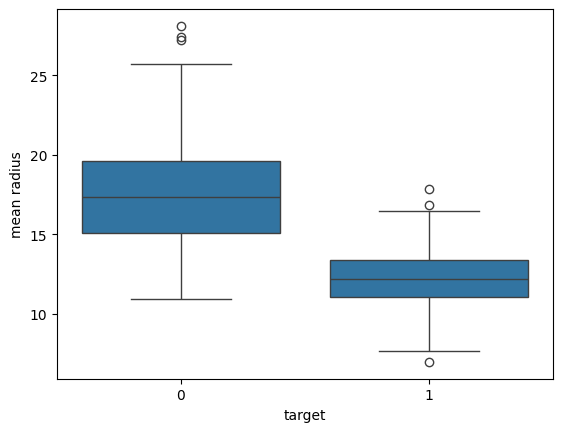

In [139]:
sns.boxplot(data=df, x="target", y="mean radius")

### 3. Correlation heatmap

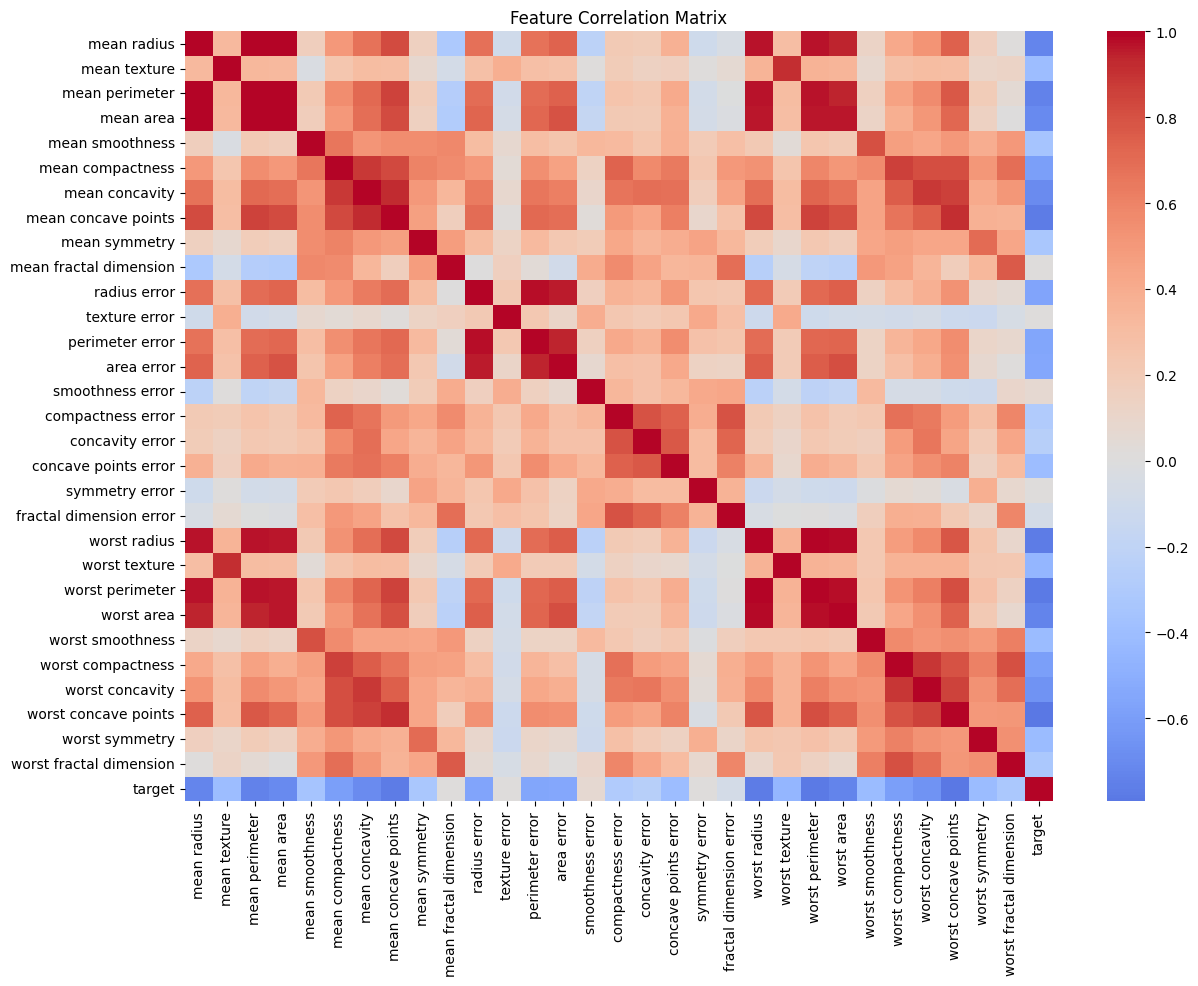

In [140]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

### 4. Feature correlation with the target

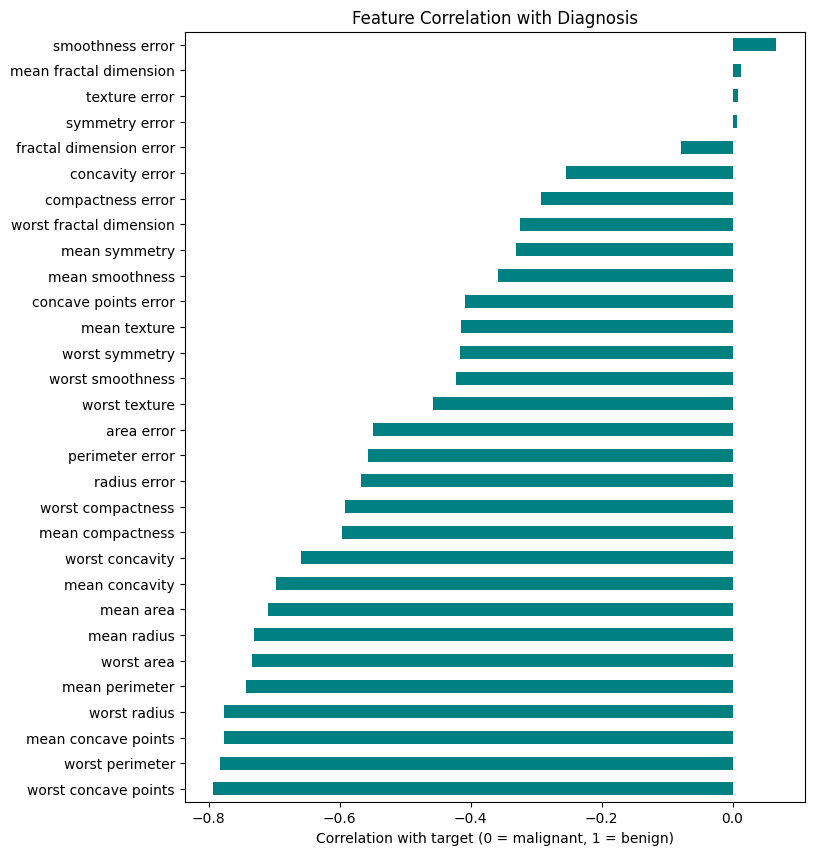

In [141]:
target_corr = (
    numeric_df.corr()["target"]
    .drop("target")
    .sort_values()
)

plt.figure(figsize=(8, 10))
target_corr.plot(kind="barh", color="teal")
plt.title("Feature Correlation with Diagnosis")
plt.xlabel("Correlation with target (0 = malignant, 1 = benign)")
plt.show()

### 5. Scatter plot of two important features by diagnosis

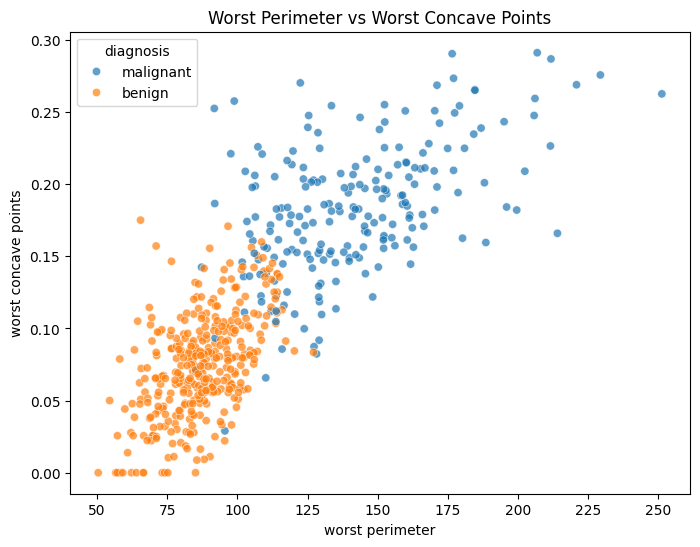

In [142]:
plt.figure(figsize=(8, 6))

# Use the two features with the largest absolute correlation with target
sns.scatterplot(
    data=df,
    x="worst perimeter",
    y="worst concave points",
    hue="diagnosis",
    alpha=0.7
)

plt.title("Worst Perimeter vs Worst Concave Points")
plt.show()

## Linear Regression using Mini Batch Gradient descent

### 1. Train Models

In [143]:
epochs = 1000

output_dir = Path("plots/breast_cancer")
output_dir.mkdir(parents=True, exist_ok=True)  # Creates the directory if it doesn't exist

def run_experiment(optimizer, X_train, y_train, X_val, y_val, X_test, y_test,
                   etas, epochs, seeds=(42, 123, 99), output_dir=None):    
    results = []
    for eta in etas:
        # train and store losses from 3 different seeds
        train_losses = []
        val_losses = []
        test_losses = []
        stop_epochs = []

        
        weight_list = []
        bias_list = []

        for seed in seeds:
            np.random.seed(seed)

            stop_epoch, val_loss, val_loss_, loss_, weight_, bias = (
            
                optimizer(
                    X_train,
                    y_train,
                    X_val=X_val,
                    y_val=y_val,
                    eta=eta,
                    epochs=epochs,
                    random_state=seed
                )
            )

            test_loss = loss(X_test, y_test, weight_, bias)

            train_losses.append(loss_[-1])
            val_losses.append(val_loss)
            test_losses.append(test_loss)
            stop_epochs.append(stop_epoch)
            weight_list.append(weight_)
            bias_list.append(bias)

            # Plot
            if output_dir is not None:

                file_path = output_dir / f"eta_{eta}_seed_{seed}.png"
                epochs_ = np.arange(stop_epoch)
                plt.figure()  # Create a fresh figure for each iteration
                plt.plot(
                    epochs_,
                    loss_,
                    color="blue",
                    linewidth=1,
                    label="training loss"
                )
                plt.plot(
                    epochs_,
                    val_loss_,
                    color="red",
                    linewidth=1,
                    label="validation loss"
                )

                plt.title("Learning Curve")
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.legend()

                plt.savefig(
                    file_path,
                    bbox_inches="tight",
                    dpi=300
                )
                plt.close()  # Close the plot to free memory and avoid line overlap


        # Best seed according to validation loss
            best_seed_idx = np.argmin(val_losses)

        results.append(
            {
                "eta": eta,
                "mean train loss": np.mean(train_losses),
                "mean val loss": np.mean(val_losses),
                "mean test loss": np.mean(test_losses),
                "std train loss": np.std(train_losses),
                "std val loss": np.std(val_losses),
                "std test loss": np.std(test_losses),
                "avg # of epoch": np.mean(stop_epochs),
                "best weights": weight_list[best_seed_idx],
                "best bias": bias_list[best_seed_idx]
            }
        )

    return results

In [144]:
etas = np.logspace(-4, -1, 15)

results_mini_batch = run_experiment(
    mini_batch_GD_val,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    etas,
    epochs,
    output_dir = output_dir
)



### 2. Evaluate Models

In [145]:
print("Training X:", X_train.shape)
print("Range of Y:",np.min(y), np.max(y))
print("\n")


df_result = pd.DataFrame(results_mini_batch)
df_result_sorted = df_result.sort_values(by="mean val loss").reset_index(drop=True)

best_model = df_result_sorted.iloc[0]
best_weight_ = best_model["best weights"]
best_bias = best_model["best bias"]

df_result_sorted.drop(columns=["best weights", "best bias"], inplace=True)
print("mini-batch Gradient Descent:\n")
print(df_result_sorted.to_string())



Training X: (341, 30)
Range of Y: 0 1


mini-batch Gradient Descent:

         eta  mean train loss  mean val loss  mean test loss  std train loss  std val loss  std test loss  avg # of epoch
0   0.100000         0.518417       0.458741        0.483951        0.011958      0.010655       0.012480       22.000000
1   0.061054         0.540356       0.494680        0.514037        0.019660      0.012212       0.006876       25.333333
2   0.037276         0.537703       0.506797        0.524628        0.015630      0.013874       0.010290       28.333333
3   0.022758         0.527954       0.510113        0.527702        0.011041      0.017299       0.013603       31.333333
4   0.013895         0.528595       0.514678        0.531571        0.016154      0.017799       0.012765       39.000000
5   0.008483         0.525841       0.517263        0.534050        0.016861      0.016266       0.010872       48.666667
6   0.005179         0.524919       0.519368        0.536700        0.019506

### 3. Best Pick

#### Two Features decision boundary

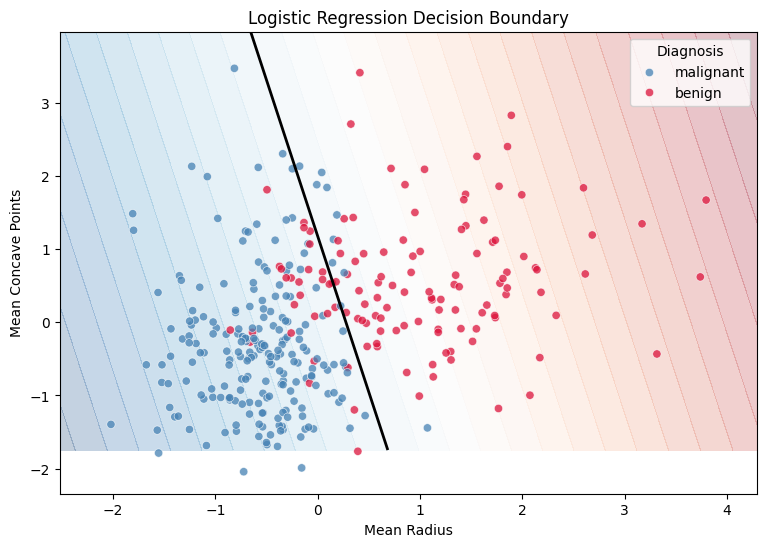

In [148]:
selected_features = ("Mean Radius", "Mean Concave Points")
i, j = (
    df.columns.get_loc(selected_features[0].lower()), 
    df.columns.get_loc(selected_features[1].lower())
)

y_pred = predict(X_val, best_weight_, best_bias)
residuals = y_val - y_pred

# Create a grid covering the original feature values
x1_min, x1_max = X_train[:, i].min() - 0.5, X_train[:, 0].max() + 0.5
x2_min, x2_max = X_train[:, j].min() - 0.5, X_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

# Scale grid using training mean/std before prediction
grid_scaled = np.c_[xx.ravel(), yy.ravel()]

# Probability of class 1 = benign
probabilities = predict_proba(grid_scaled, best_weight_[[i, j]], best_bias).reshape(xx.shape)

# Plot points and probability-0.5 boundary
plt.figure(figsize=(9, 6))

plt.contourf(xx, yy, probabilities, levels=30, cmap="RdBu", alpha=0.25)

plt.contour(
    xx, yy, probabilities,
    levels=[0.5],
    colors="black",
    linewidths=2
)

sns.scatterplot(
    x=X_train[:, 0],
    y=X_train[:, 1],
    hue=y_train,
    palette={0: "crimson", 1: "steelblue"},
    alpha=0.75
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Concave Points")
plt.title("Logistic Regression Decision Boundary")
plt.legend(title="Diagnosis", labels=["malignant", "benign"])
plt.show()

#### Confusion matrix

In [149]:
matrix = np.zeros((2, 2), dtype=int)

for actual, predicted in zip(y_val, y_pred):
    matrix[actual, predicted] += 1

df_matrix = pd.DataFrame(matrix, columns=["Malignant", "Benign"], index=["Malignant", "Benign"])
df_matrix.columns.name = "Actual/Predicted"
print(df_matrix)
print("\n")

print(pd.Series({
"Accuracy": accuracy_score(y_val, y_pred),
"Balanced accuracy": balanced_accuracy_score(y_val, y_pred),
"Malignant precision": precision_score(y_val, y_pred, pos_label=0),
"Malignant recall": recall_score(y_val, y_pred, pos_label=0),
"Malignant F1": f1_score(y_val, y_pred, pos_label=0),
}))

Actual/Predicted  Malignant  Benign
Malignant                43       0
Benign                    2      69


Accuracy               0.982456
Balanced accuracy      0.985915
Malignant precision    0.955556
Malignant recall       1.000000
Malignant F1           0.977273
dtype: float64


### 4. Retrain Model on Train + Val Sets (Optional)

In [150]:
best_eta = df_result_sorted.iloc[0]["eta"]
best_epochs = df_result_sorted.iloc[0]["avg # of epoch"]
loss_, weight_, bias = mini_batch_GD(X_train_val, y_train_val, eta=best_eta, epochs=int(best_epochs))
test_loss = loss(X_test, y_test, weight_, bias)
y_pred = predict(X_test, weight_, bias)

matrix = np.zeros((2, 2), dtype=int)

for actual, predicted in zip(y_test, y_pred):
    matrix[actual, predicted] += 1

df_matrix = pd.DataFrame(matrix, columns=["Malignant", "Benign"], index=["Malignant", "Benign"])
df_matrix.columns.name = "Actual/Predicted"
print(df_matrix)
print("\n")

retrain_model = pd.Series({
    "eta": best_eta,
    "# of epochs": best_epochs,
    "train loss": loss_[-1],
    "test loss": test_loss,
    "Training Accuracy Score": accuracy_score(y_train_val, predict(X_train_val, weight_, bias)),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
    "Malignant precision": precision_score(y_test, y_pred, pos_label=0),
    "Malignant recall": recall_score(y_test, y_pred, pos_label=0),
    "Malignant F1": f1_score(y_test, y_pred, pos_label=0)

})
print(retrain_model)



Actual/Predicted  Malignant  Benign
Malignant                41       1
Benign                    2      70


eta                         0.100000
# of epochs                22.000000
train loss                  0.529398
test loss                   0.538854
Training Accuracy Score     0.980220
Accuracy                    0.973684
Balanced accuracy           0.974206
Malignant precision         0.953488
Malignant recall            0.976190
Malignant F1                0.964706
dtype: float64


## Redo for Stochastic Gradient Descent

### Training

In [151]:
results_stochastic = run_experiment(
    SGD_val,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    etas,
    epochs,
    output_dir = output_dir
)


### Evaluation

In [152]:
df_result = pd.DataFrame(results_stochastic)
df_result_sorted = df_result.sort_values(by="mean val loss").reset_index(drop=True)

best_model = df_result_sorted.iloc[0]
best_weight_ = best_model["best weights"]
best_bias = best_model["best bias"]

df_result_sorted.drop(columns=["best weights", "best bias"], inplace=True)
print("Stochastic Gradient Descent:\n")
print(df_result_sorted.to_string())

Stochastic Gradient Descent:

         eta  mean train loss  mean val loss  mean test loss  std train loss  std val loss  std test loss  avg # of epoch
0   0.100000         0.078197       0.054211        0.087072        0.009789      0.002520       0.002895       33.666667
1   0.061054         0.110286       0.076603        0.117622        0.009109      0.008820       0.009049       42.333333
2   0.037276         0.184661       0.136760        0.186346        0.014433      0.002164       0.002830       44.666667
3   0.022758         0.266659       0.209868        0.248201        0.025777      0.009879       0.012837       60.333333
4   0.013895         0.346675       0.306074        0.333517        0.037359      0.022562       0.022301       76.000000
5   0.008483         0.446064       0.397546        0.422958        0.027072      0.022093       0.023503       52.333333
6   0.005179         0.525752       0.470021        0.494105        0.010872      0.016541       0.017006       22.3

### Best Pick

#### Two Features decision boundary

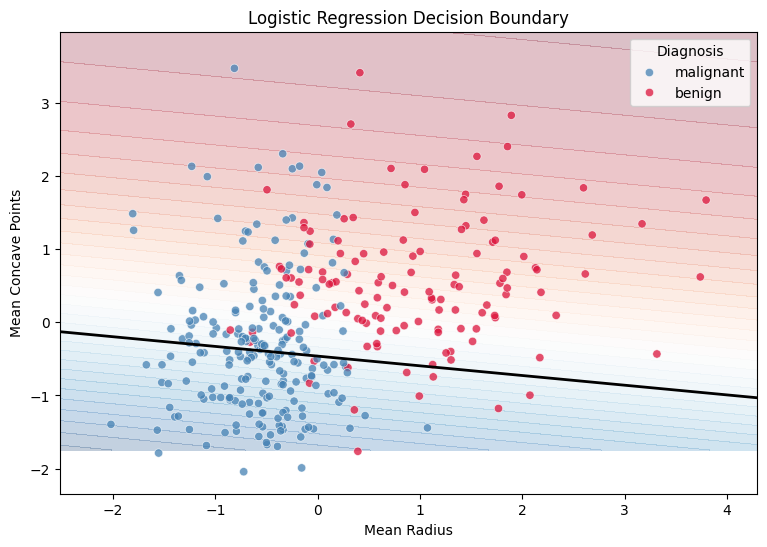

In [153]:
i,j = 0, 7

y_pred = predict(X_val, best_weight_, best_bias)
residuals = y_val - y_pred

# Create a grid covering the original feature values
x1_min, x1_max = X_train[:, i].min() - 0.5, X_train[:, 0].max() + 0.5
x2_min, x2_max = X_train[:, j].min() - 0.5, X_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

# Scale grid using training mean/std before prediction
grid_scaled = np.c_[xx.ravel(), yy.ravel()]

# Probability of class 1 = benign
probabilities = predict_proba(grid_scaled, best_weight_[[i, j]], best_bias).reshape(xx.shape)

# Plot points and probability-0.5 boundary
plt.figure(figsize=(9, 6))

plt.contourf(xx, yy, probabilities, levels=30, cmap="RdBu", alpha=0.25)

plt.contour(
    xx, yy, probabilities,
    levels=[0.5],
    colors="black",
    linewidths=2
)

sns.scatterplot(
    x=X_train[:, 0],
    y=X_train[:, 1],
    hue=y_train,
    palette={0: "crimson", 1: "steelblue"},
    alpha=0.75
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Concave Points")
plt.title("Logistic Regression Decision Boundary")
plt.legend(title="Diagnosis", labels=["malignant", "benign"])
plt.show()

#### Confusion matrix

In [154]:
matrix = np.zeros((2, 2), dtype=int)

for actual, predicted in zip(y_val, y_pred):
    matrix[actual, predicted] += 1

df_matrix = pd.DataFrame(matrix, columns=["Malignant", "Benign"], index=["Malignant", "Benign"])
df_matrix.columns.name = "Actual/Predicted"
print(df_matrix)
print("\n")

print(pd.Series({
"Accuracy": accuracy_score(y_val, y_pred),
"Balanced accuracy": balanced_accuracy_score(y_val, y_pred),
"Malignant precision": precision_score(y_val, y_pred, pos_label=0),
"Malignant recall": recall_score(y_val, y_pred, pos_label=0),
"Malignant F1": f1_score(y_val, y_pred, pos_label=0),
}))

Actual/Predicted  Malignant  Benign
Malignant                42       1
Benign                    0      71


Accuracy               0.991228
Balanced accuracy      0.988372
Malignant precision    1.000000
Malignant recall       0.976744
Malignant F1           0.988235
dtype: float64


### Retrain (Optional)

In [157]:
best_eta = df_result_sorted.iloc[0]["eta"]
best_epochs = df_result_sorted.iloc[0]["avg # of epoch"]
loss_, weight_, bias = SGD(X_train_val, y_train_val, eta=best_eta, epochs=int(best_epochs))
test_loss = loss(X_test, y_test, weight_, bias)
y_pred = predict(X_test, weight_, bias)

matrix = np.zeros((2, 2), dtype=int)

for actual, predicted in zip(y_test, y_pred):
    matrix[actual, predicted] += 1

df_matrix = pd.DataFrame(matrix, columns=["Malignant", "Benign"], index=["Malignant", "Benign"])
df_matrix.columns.name = "Actual/Predicted"
print(df_matrix)
print("\n")

retrain_model = pd.Series({
    "eta": best_eta,
    "# of epochs": best_epochs,
    "train loss": loss_[-1],
    "test loss": test_loss,
    "Training Accuracy Score": accuracy_score(y_train_val, predict(X_train_val, weight_, bias)),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
    "Malignant precision": precision_score(y_test, y_pred, pos_label=0),
    "Malignant recall": recall_score(y_test, y_pred, pos_label=0),
    "Malignant F1": f1_score(y_test, y_pred, pos_label=0)

})
print(retrain_model)



Actual/Predicted  Malignant  Benign
Malignant                41       1
Benign                    5      67


eta                         0.100000
# of epochs                33.666667
train loss                  0.099499
test loss                   0.134282
Training Accuracy Score     0.971429
Accuracy                    0.947368
Balanced accuracy           0.953373
Malignant precision         0.891304
Malignant recall            0.976190
Malignant F1                0.931818
dtype: float64
